# Fairness with Adaptive Weights — Reproduction Notebook

Reproduction of **Chai & Wang, ICML 2022 — "Fairness with Adaptive Weights"** on two UCI datasets (Adult, German Credit), compared against three standard ML baselines (Logistic Regression, Random Forest, SVM).

**Author:** Santhana Krishnan A, ED23B059 (IIT Madras — DA5400 - Foundations of Machine Learning bonus assignment)

## What this notebook does
1. Loads Adult and German Credit from UCI.
2. Implements the paper's closed-form weight assignment (Theorem 3.1) and Algorithm 1.
3. Trains 3 baseline classifiers (LR, RF, SVM) without any fairness intervention.
4. Trains Logistic Regression with the paper's Adaptive Reweighing wrapper.
5. Evaluates Accuracy, Disparate Impact, Disparate TPR, Disparate TNR (mean ± std over 5 seeds).
6. Produces a results table and accuracy-vs-fairness scatter, plus an α-sensitivity plot.

## 0. Setup

In [1]:
!pip -q install ucimlrepo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

RNG_SEEDS = [0, 1, 2, 3, 4]
TEST_SIZE = 0.2

## 1. Data loaders

We define one loader per dataset. Each returns `X` (numpy array of features, sensitive column **dropped**), `y` (binary 0/1 target), `s` (binary 0/1 sensitive attribute).

Convention: `s=1` is the majority/privileged group, `s=0` is the minority/unprivileged group. `y=1` is the favourable outcome (high income / good credit).

In [ ]:
def load_adult():
    ds = fetch_ucirepo(id=2)
    df = pd.concat([ds.data.features, ds.data.targets], axis=1).dropna()
    target_col = ds.data.targets.columns[0]
    df[target_col] = df[target_col].astype(str).str.strip().str.rstrip('.')
    y = (df[target_col] == '>50K').astype(int).values

    s = (df['sex'].astype(str).str.strip() == 'Male').astype(int).values

    feat_df = df.drop(columns=[target_col, 'sex'])
    feat_df = pd.get_dummies(feat_df, drop_first=True)
    X = StandardScaler().fit_transform(feat_df.values.astype(float))
    return X, y, s


def load_german():
    ds = fetch_ucirepo(id=144)
    df = pd.concat([ds.data.features, ds.data.targets], axis=1).dropna()
    target_col = ds.data.targets.columns[0]

    pstatus_col = None
    for c in df.columns:
        if df[c].dtype == object and df[c].astype(str).str.startswith('A9').any():
            pstatus_col = c
            break
    assert pstatus_col is not None, 'Could not locate personal-status column'

    male_codes = {'A91', 'A93', 'A94'}
    s = df[pstatus_col].astype(str).str.strip().isin(male_codes).astype(int).values
    y = (df[target_col].astype(int) == 1).astype(int).values

    feat_df = df.drop(columns=[target_col, pstatus_col])
    feat_df = pd.get_dummies(feat_df, drop_first=True)
    X = StandardScaler().fit_transform(feat_df.values.astype(float))
    return X, y, s

for name, loader in [('Adult', load_adult), ('German', load_german)]:
    X, y, s = loader()
    print(f'{name}: X={X.shape}, y mean={y.mean():.3f}, s mean={s.mean():.3f}')
    print(f'   subgroup sizes (y,s):',
          {(yy, ss): int(((y == yy) & (s == ss)).sum()) for yy in [0, 1] for ss in [0, 1]})


Adult: X=(47621, 99), y mean=0.242, s mean=0.671
   subgroup sizes (y,s): {(0, 0): 13948, (0, 1): 22132, (1, 0): 1736, (1, 1): 9805}
German: X=(1000, 45), y mean=0.700, s mean=0.690
   subgroup sizes (y,s): {(0, 0): 109, (0, 1): 191, (1, 0): 201, (1, 1): 499}


## 2. Fairness metrics

All three gap metrics: lower is better. They follow the definitions in the paper (Section 3.1).

In [ ]:
def fairness_metrics(y_true, y_pred, s):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    s = np.asarray(s).astype(int)

    def rate(mask):
        return y_pred[mask].mean() if mask.sum() else 0.0

    def tpr(mask):
        m = mask & (y_true == 1)
        return y_pred[m].mean() if m.sum() else 0.0

    def tnr(mask):
        m = mask & (y_true == 0)
        return (1 - y_pred[m]).mean() if m.sum() else 0.0

    s0, s1 = (s == 0), (s == 1)
    return {
        'acc'        : float(accuracy_score(y_true, y_pred)),
        'disp_impact': float(abs(rate(s0) - rate(s1))),
        'disp_tpr'   : float(abs(tpr(s0) - tpr(s1))),
        'disp_tnr'   : float(abs(tnr(s0) - tnr(s1))),
    }


## 3. Closed-form weight solver (Theorem 3.1)

In [ ]:
def solve_subgroup_weights(losses, alpha, c):
    losses = np.asarray(losses, dtype=float)
    n = len(losses)
    if n == 0:
        return np.zeros(0)
    order = np.argsort(-losses)
    sorted_l = losses[order]

    cum = 0.0
    lam = None
    for k in range(1, n + 1):
        cum += sorted_l[k - 1]
        cand = (cum - 2.0 * alpha * c) / k
        upper = sorted_l[k - 1]
        lower = sorted_l[k] if k < n else -np.inf
        if lower - 1e-12 <= cand <= upper + 1e-12:
            lam = cand
            break
    if lam is None:
        lam = (sorted_l.sum() - 2.0 * alpha * c) / n
    w = np.maximum((losses - lam) / (2.0 * alpha), 0.0)
    return w

_l = np.array([5.0, 4.0, 3.0, 1.0, 0.5])
_w = solve_subgroup_weights(_l, alpha=1.0, c=2.0)
print('Test losses :', _l)
print('Test weights:', _w.round(4), '  sum =', _w.sum().round(4), '(target c=2)')


Test losses : [5.  4.  3.  1.  0.5]
Test weights: [1.1667 0.6667 0.1667 0.     0.    ]   sum = 2.0 (target c=2)


## 4. Adaptive Reweighing wrapper

In [ ]:
def per_sample_logloss(clf, X, y):
    p = clf.predict_proba(X)[:, 1]
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


def adaptive_reweigh_fit(X, y, s, base_factory, alpha=10.0,
                         max_iter=15, tol=1e-3, verbose=False):
    n = len(X)
    y = y.astype(int); s = s.astype(int)
    subgroup_idx = {}
    for yy in [0, 1]:
        for ss in [0, 1]:
            mask = (y == yy) & (s == ss)
            if mask.sum() > 0:
                subgroup_idx[(yy, ss)] = np.where(mask)[0]
    c = max(len(ix) for ix in subgroup_idx.values())
    w = np.ones(n)
    clf = base_factory()
    clf.fit(X, y, sample_weight=w)

    history = []
    for it in range(max_iter):
        losses = per_sample_logloss(clf, X, y)
        new_w = np.zeros(n)
        for key, idx in subgroup_idx.items():
            new_w[idx] = solve_subgroup_weights(losses[idx], alpha=alpha, c=c)
        if new_w.sum() < 1e-9:
            new_w = np.ones(n)

        clf = base_factory()
        clf.fit(X, y, sample_weight=new_w)

        delta = np.linalg.norm(new_w - w) / (np.linalg.norm(w) + 1e-9)
        history.append({'iter': it, 'delta': float(delta),
                        'nonzero_frac': float((new_w > 0).mean())})
        if verbose:
            print(f'  iter {it:02d}  Δw={delta:.4f}  nonzero={new_w.mean():.3f}')
        if delta < tol:
            break
        w = new_w

    return clf, new_w, history


## 5. Experiment runner — 4 methods × 2 datasets × 5 seeds

In [ ]:
from sklearn.svm import LinearSVC
def lr_factory():
    return LogisticRegression(max_iter=1000, solver='liblinear')

def rf_factory():
    return RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)

def svm_factory():
    return LinearSVC(C=1.0, max_iter=2000, random_state=0, dual='auto')


def run_single(X_tr, y_tr, s_tr, X_te, y_te, s_te, method, alpha=10.0):
    if method == 'LR':
        clf = lr_factory();      clf.fit(X_tr, y_tr)
    elif method == 'RF':
        clf = rf_factory();      clf.fit(X_tr, y_tr)
    elif method == 'SVM':
        clf = svm_factory();     clf.fit(X_tr, y_tr)
    elif method == 'LR+Adaptive':
        clf, _, _ = adaptive_reweigh_fit(X_tr, y_tr, s_tr,
                                         base_factory=lr_factory,
                                         alpha=alpha)
    else:
        raise ValueError(method)
    y_hat = clf.predict(X_te)
    return fairness_metrics(y_te, y_hat, s_te)


def run_experiment(loader, dataset_name, alpha=10.0):
    X, y, s = loader()
    methods = ['LR', 'RF', 'SVM', 'LR+Adaptive']
    rows = []
    for seed in RNG_SEEDS:
        X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(
            X, y, s, test_size=TEST_SIZE, random_state=seed, stratify=y)
        for m in methods:
            metrics = run_single(X_tr, y_tr, s_tr, X_te, y_te, s_te, m, alpha=alpha)
            metrics.update({'dataset': dataset_name, 'method': m, 'seed': seed})
            rows.append(metrics)
            print(f'{dataset_name} | seed={seed} | {m:14s} '
                  f'acc={metrics["acc"]:.4f}  DI={metrics["disp_impact"]:.4f}  '
                  f'dTPR={metrics["disp_tpr"]:.4f}  dTNR={metrics["disp_tnr"]:.4f}')
    return pd.DataFrame(rows)


In [9]:
results_adult  = run_experiment(load_adult,  'Adult',  alpha=10.0)
results_german = run_experiment(load_german, 'German', alpha=2.0)
all_results = pd.concat([results_adult, results_german], ignore_index=True)
all_results.to_csv('raw_results.csv', index=False)
print('\nSaved raw_results.csv')

Adult | seed=0 | LR             acc=0.8541  DI=0.1871  dTPR=0.1112  dTNR=0.0756
Adult | seed=0 | RF             acc=0.8543  DI=0.1932  dTPR=0.0940  dTNR=0.0806
Adult | seed=0 | SVM            acc=0.8534  DI=0.1827  dTPR=0.1186  dTNR=0.0706
Adult | seed=0 | LR+Adaptive    acc=0.8153  DI=0.2079  dTPR=0.0211  dTNR=0.0975
Adult | seed=1 | LR             acc=0.8491  DI=0.1649  dTPR=0.1139  dTNR=0.0626
Adult | seed=1 | RF             acc=0.8534  DI=0.1760  dTPR=0.1083  dTNR=0.0724
Adult | seed=1 | SVM            acc=0.8484  DI=0.1597  dTPR=0.1134  dTNR=0.0587
Adult | seed=1 | LR+Adaptive    acc=0.8135  DI=0.1992  dTPR=0.0148  dTNR=0.1001
Adult | seed=2 | LR             acc=0.8546  DI=0.1759  dTPR=0.0756  dTNR=0.0677
Adult | seed=2 | RF             acc=0.8573  DI=0.1908  dTPR=0.0551  dTNR=0.0848
Adult | seed=2 | SVM            acc=0.8536  DI=0.1694  dTPR=0.0633  dTNR=0.0644
Adult | seed=2 | LR+Adaptive    acc=0.8199  DI=0.2032  dTPR=0.0455  dTNR=0.0980
Adult | seed=3 | LR             acc=0.84

## 6. Aggregate — mean ± std table (paper's reporting format)

In [ ]:
def summarise(df):
    g = df.groupby(['dataset', 'method'])
    mean = g[['acc', 'disp_impact', 'disp_tpr', 'disp_tnr']].mean()
    std  = g[['acc', 'disp_impact', 'disp_tpr', 'disp_tnr']].std()
    out = mean.copy()
    for col in mean.columns:
        out[col] = mean[col].round(4).astype(str) + ' ± ' + std[col].round(4).astype(str)
    order = ['LR', 'RF', 'SVM', 'LR+Adaptive']
    out = out.reset_index()
    out['method'] = pd.Categorical(out['method'], categories=order, ordered=True)
    return out.sort_values(['dataset', 'method']).reset_index(drop=True)

summary = summarise(all_results)
summary

,dataset,method,acc,disp_impact,disp_tpr,disp_tnr
0,Adult,LR,0.8506 ± 0.0036,0.1738 ± 0.0085,0.0876 ± 0.0302,0.0706 ± 0.007
1,Adult,RF,0.8525 ± 0.0038,0.1791 ± 0.0123,0.0727 ± 0.0337,0.0754 ± 0.0088
2,Adult,SVM,0.8505 ± 0.0031,0.1681 ± 0.0089,0.0861 ± 0.0336,0.0657 ± 0.0064
3,Adult,LR+Adaptive,0.8121 ± 0.0062,0.1979 ± 0.0089,0.0285 ± 0.0182,0.0968 ± 0.0026
4,German,LR,0.754 ± 0.0413,0.0862 ± 0.0719,0.0719 ± 0.0267,0.1018 ± 0.083
5,German,RF,0.75 ± 0.0278,0.0642 ± 0.0359,0.0505 ± 0.0402,0.0369 ± 0.0268
6,German,SVM,0.758 ± 0.0412,0.0833 ± 0.0708,0.0647 ± 0.0191,0.1163 ± 0.0796
7,German,LR+Adaptive,0.707 ± 0.0432,0.0617 ± 0.0362,0.0674 ± 0.0549,0.0898 ± 0.0253


## 7. Accuracy vs. fairness scatter plot

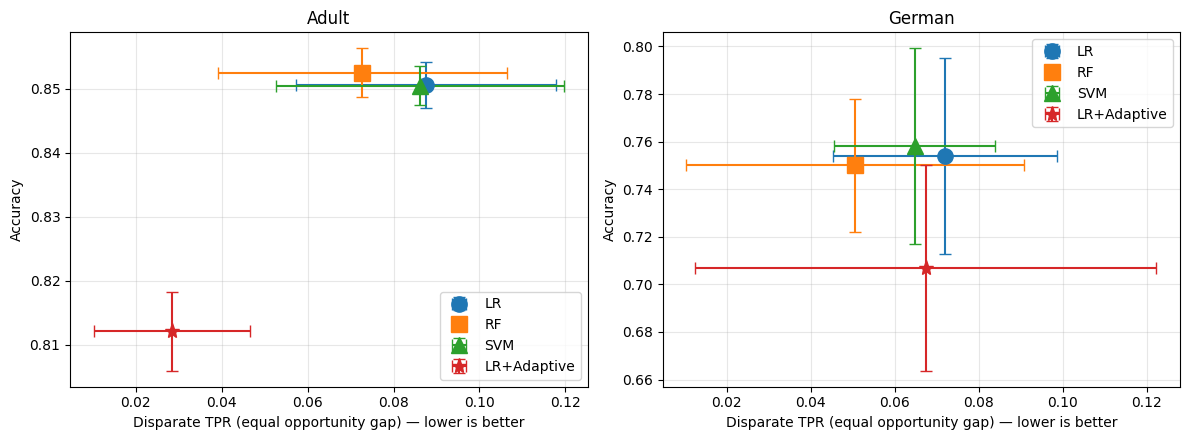

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, dataset in zip(axes, ['Adult', 'German']):
    sub = all_results[all_results['dataset'] == dataset]
    for m, marker in [('LR','o'),('RF','s'),('SVM','^'),('LR+Adaptive','*')]:
        d = sub[sub['method'] == m]
        ax.errorbar(d['disp_tpr'].mean(), d['acc'].mean(),
                    xerr=d['disp_tpr'].std(), yerr=d['acc'].std(),
                    fmt=marker, markersize=11, capsize=4, label=m)
    ax.set_xlabel('Disparate TPR (equal opportunity gap) — lower is better')
    ax.set_ylabel('Accuracy')
    ax.set_title(dataset)
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig('accuracy_vs_fairness.png', dpi=150)
plt.show()

## 8. α-sensitivity sweep

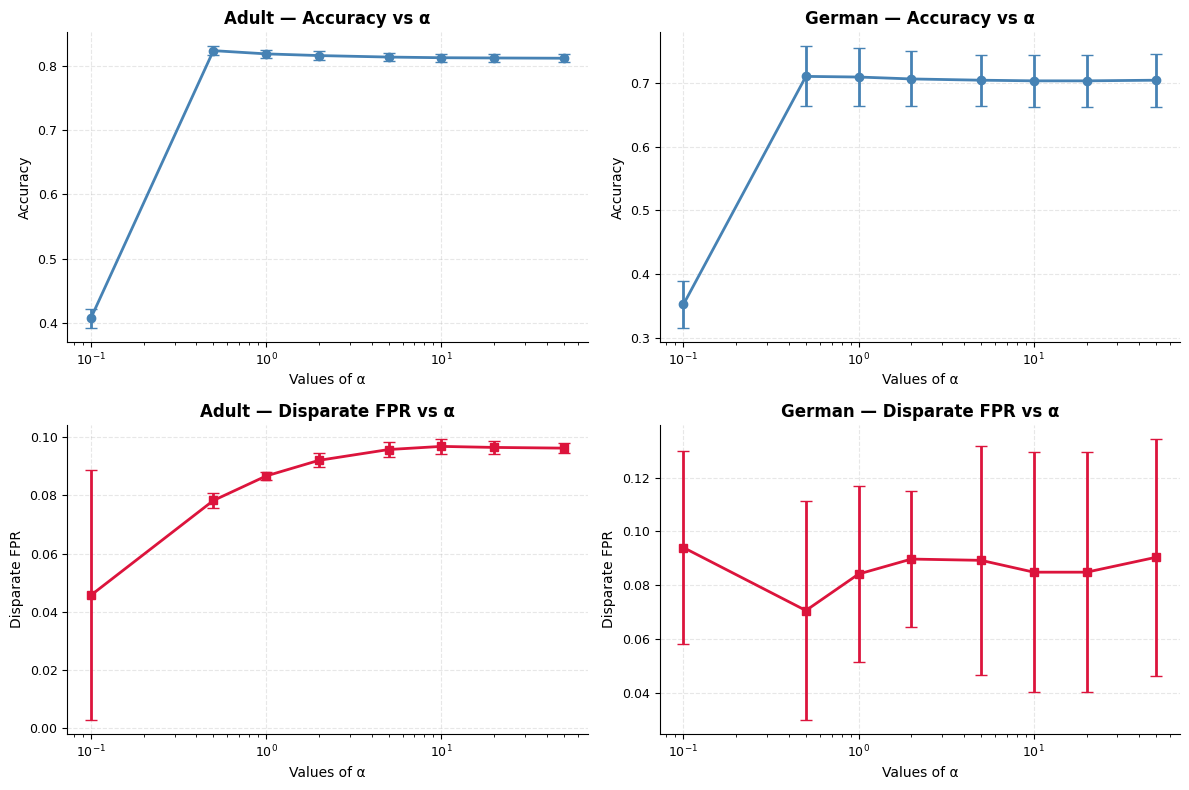

✅ Saved alpha_sensitivity.png — matches paper Figure 4 layout


In [ ]:
def alpha_sweep(loader, dataset_name, alphas):
    X, y, s = loader()
    rows = []
    for seed in RNG_SEEDS:
        X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(
            X, y, s, test_size=TEST_SIZE, random_state=seed, stratify=y)
        for a in alphas:
            m = run_single(X_tr, y_tr, s_tr, X_te, y_te, s_te,
                            'LR+Adaptive', alpha=a)
            m.update({'alpha': a, 'seed': seed, 'dataset': dataset_name})
            rows.append(m)
    return pd.DataFrame(rows)

alphas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
sweep_adult  = alpha_sweep(load_adult,  'Adult',  alphas)
sweep_german = alpha_sweep(load_german, 'German', alphas)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (sweep, name) in enumerate([(sweep_adult, 'Adult'),
                                      (sweep_german, 'German')]):
    g = sweep.groupby('alpha').agg(
        acc_mean=('acc', 'mean'),       acc_std=('acc', 'std'),
        tnr_mean=('disp_tnr', 'mean'),  tnr_std=('disp_tnr', 'std'),
    )

    ax = axes[0, col]
    ax.errorbar(g.index, g['acc_mean'], yerr=g['acc_std'],
                marker='o', color='steelblue', capsize=4,
                linewidth=2, markersize=6)
    ax.set_xscale('log')
    ax.set_title(f'{name} — Accuracy vs α', fontsize=12, weight='bold')
    ax.set_xlabel('Values of α', fontsize=10)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)

    ax = axes[1, col]
    ax.errorbar(g.index, g['tnr_mean'], yerr=g['tnr_std'],
                marker='s', color='crimson', capsize=4,
                linewidth=2, markersize=6)
    ax.set_xscale('log')
    ax.set_title(f'{name} — Disparate FPR vs α', fontsize=12, weight='bold')
    ax.set_xlabel('Values of α', fontsize=10)
    ax.set_ylabel('Disparate FPR', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('alpha_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved alpha_sensitivity.png')

## 9. Noise Robustness Analysis

In [ ]:
def inject_noise(y, noise_ratio, s, seed=0):
    rng = np.random.default_rng(seed)
    y_noisy = y.copy()
    for group in [0, 1]:
        group_idx = np.where(s == group)[0]
        n_flip = int(len(group_idx) * noise_ratio)
        if n_flip > 0:
            flip_idx = rng.choice(group_idx, size=n_flip, replace=False)
            y_noisy[flip_idx] = 1 - y_noisy[flip_idx]
    return y_noisy


def noise_experiment_all(loader, dataset_name,
                         noise_ratios=[0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]):
    X, y, s = loader()
    methods = ['LR', 'RF', 'SVM', 'LR+Adaptive']
    rows = []
    for noise in noise_ratios:
        for seed in RNG_SEEDS:
            X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(
                X, y, s, test_size=TEST_SIZE, random_state=seed, stratify=y)
            if noise > 0:
                y_tr = inject_noise(y_tr, noise, s_tr, seed=seed)
            for m in methods:
                metrics = run_single(X_tr, y_tr, s_tr, X_te, y_te, s_te, m, alpha=10.0)
                metrics.update({'noise': noise, 'method': m, 'seed': seed,
                                'dataset': dataset_name})
                rows.append(metrics)
        print(f'  {dataset_name} | noise={noise:.0%} done')
    return pd.DataFrame(rows)


print('Running noise robustness (all methods) on Adult...')
noise_adult = noise_experiment_all(load_adult, 'Adult')
print('Running noise robustness (all methods) on German...')
noise_german = noise_experiment_all(load_german, 'German')
noise_all = pd.concat([noise_adult, noise_german], ignore_index=True)
noise_all.to_csv('noise_robustness_results.csv', index=False)
print('Saved noise_robustness_results.csv')

Running noise robustness (all methods) on Adult...
  Adult | noise=0% done
  Adult | noise=5% done
  Adult | noise=10% done
  Adult | noise=15% done
  Adult | noise=20% done
  Adult | noise=25% done
  Adult | noise=30% done
Running noise robustness (all methods) on German...
  German | noise=0% done
  German | noise=5% done
  German | noise=10% done
  German | noise=15% done
  German | noise=20% done
  German | noise=25% done
  German | noise=30% done
✅ Done — saved noise_robustness_results.csv


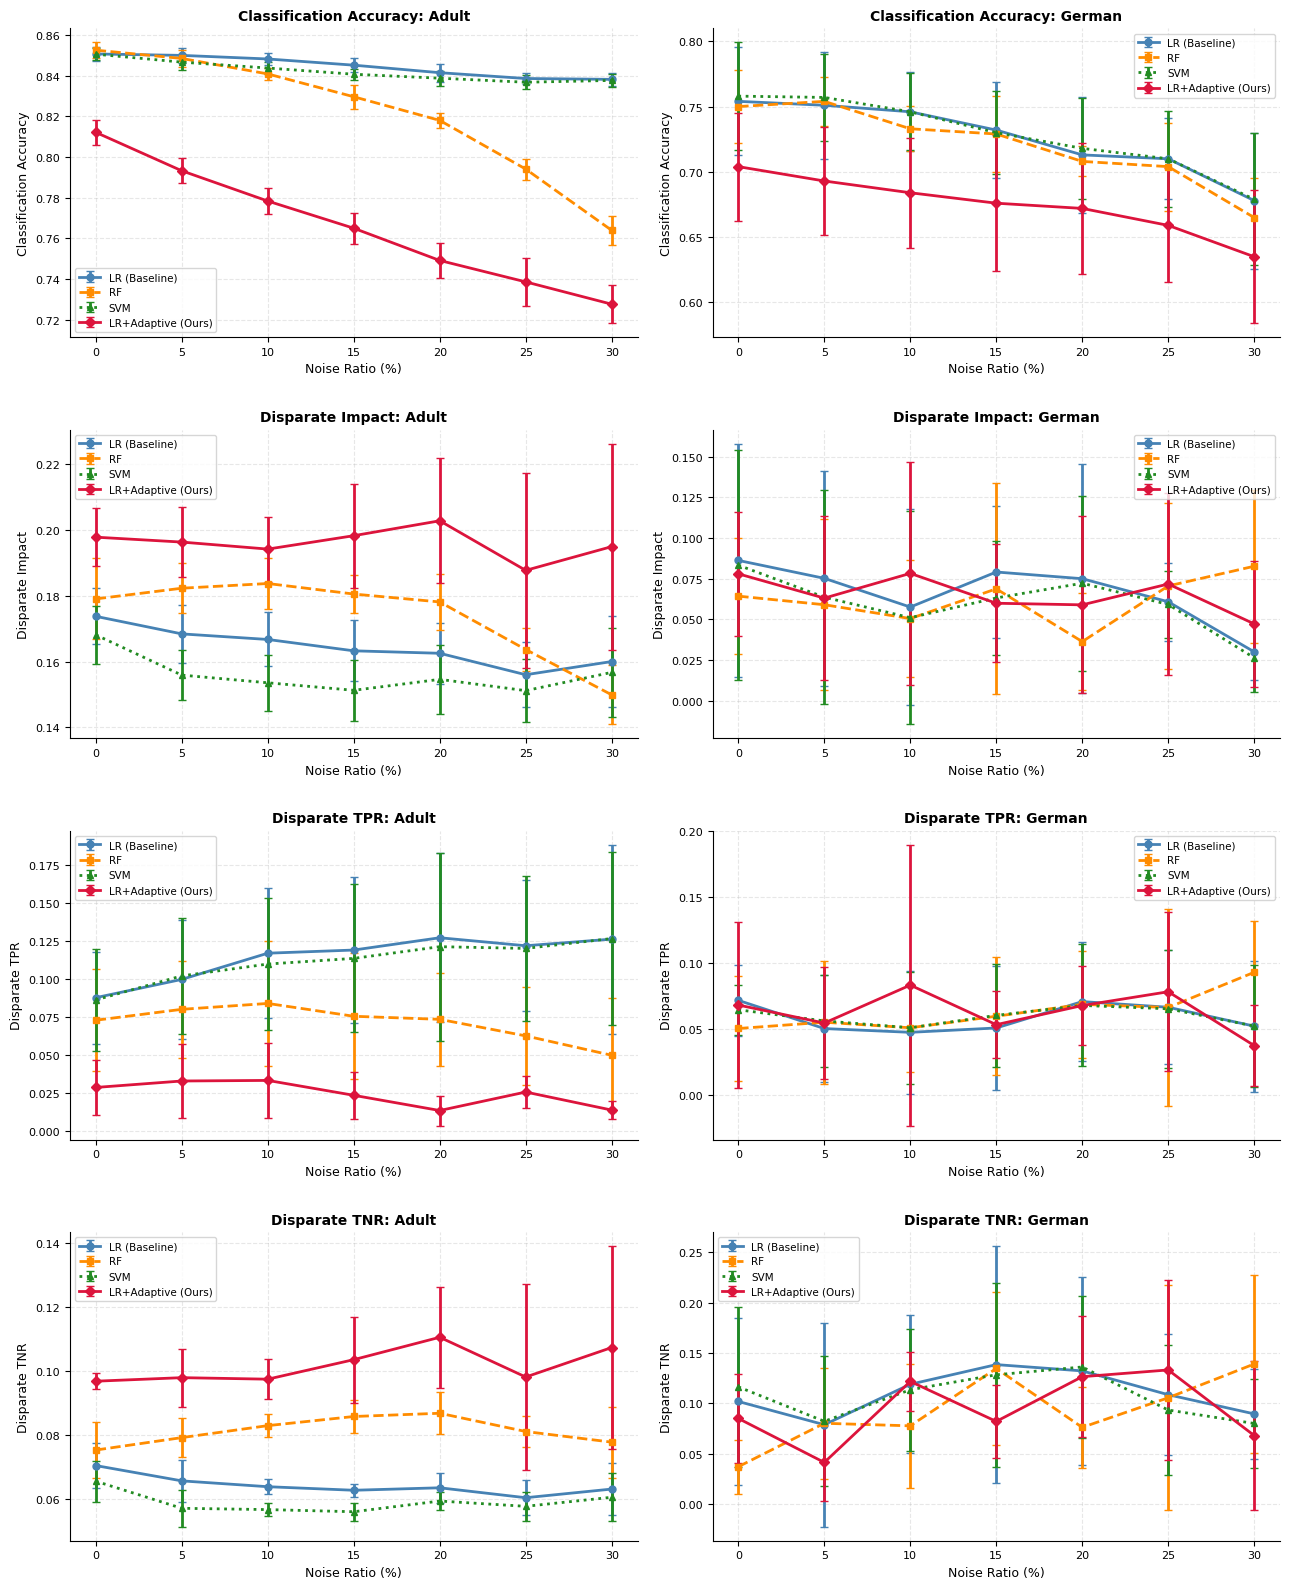

✅ Saved noise_robustness.png


In [ ]:
METHOD_STYLES = {
    'LR'          : dict(color='steelblue', marker='o', ls='-',  label='LR (Baseline)'),
    'RF'          : dict(color='darkorange', marker='s', ls='--', label='RF'),
    'SVM'         : dict(color='forestgreen', marker='^', ls=':', label='SVM'),
    'LR+Adaptive' : dict(color='crimson',    marker='D', ls='-',  label='LR+Adaptive (Ours)'),
}

metrics_plot = [
    ('acc',         'Classification Accuracy'),
    ('disp_impact', 'Disparate Impact'),
    ('disp_tpr',    'Disparate TPR'),
    ('disp_tnr',    'Disparate TNR'),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))

for col, dataset in enumerate(['Adult', 'German']):
    sub = noise_all[noise_all['dataset'] == dataset]
    for row, (metric, label) in enumerate(metrics_plot):
        ax = axes[row, col]
        for m, style in METHOD_STYLES.items():
            d = sub[sub['method'] == m]
            g = d.groupby('noise')[metric].agg(['mean', 'std'])
            ax.errorbar(
                g.index * 100,
                g['mean'],
                yerr=g['std'],
                marker=style['marker'],
                color=style['color'],
                linestyle=style['ls'],
                label=style['label'],
                capsize=3,
                linewidth=2,
                markersize=5,
            )
        ax.set_xlabel('Noise Ratio (%)', fontsize=9)
        ax.set_ylabel(label, fontsize=9)
        ax.set_title(f'{label}: {dataset}', fontsize=10, weight='bold')
        ax.legend(fontsize=7.5, loc='best')
        ax.grid(alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=8)

plt.tight_layout(h_pad=2.5)
plt.savefig('noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved noise_robustness.png')